# ANOMALY DETECTION OF FINANCIAL TIME-SERIES DATA USING A HYBRID OF STATISTICAL AND MACHINE LEARNING MODELS 

### IMPORTING LIBRARIES

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.ensemble import IsolationForest
from sklearn.metrics import mean_squared_error, precision_score, recall_score, f1_score
from statsmodels.tsa.api import VAR
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.optimizers import Adam

In [2]:
df =pd.read_csv('Microsoft_stock_data.csv', parse_dates=['Date'])

In [3]:
df.set_index('Date', inplace=True)

### EXPLORATORY DATA ANALYSIS

In [4]:
df.head()

,Close,High,Low,Open,Volume
Date,,,,,
1986-03-13,0.059500,0.062157,0.054188,0.054188,1031788800
1986-03-14,0.061625,0.062688,0.059500,0.059500,308160000
1986-03-17,0.062688,0.063219,0.061625,0.061625,133171200
1986-03-18,0.061093,0.063219,0.060562,0.062688,67766400
1986-03-19,0.060031,0.061625,0.059500,0.061093,47894400


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 9958 entries, 1986-03-13 to 2025-09-19
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Close   9958 non-null   float64
 1   High    9958 non-null   float64
 2   Low     9958 non-null   float64
 3   Open    9958 non-null   float64
 4   Volume  9958 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 466.8 KB


In [6]:
df.head()

,Close,High,Low,Open,Volume
Date,,,,,
1986-03-13,0.059500,0.062157,0.054188,0.054188,1031788800
1986-03-14,0.061625,0.062688,0.059500,0.059500,308160000
1986-03-17,0.062688,0.063219,0.061625,0.061625,133171200
1986-03-18,0.061093,0.063219,0.060562,0.062688,67766400
1986-03-19,0.060031,0.061625,0.059500,0.061093,47894400


SPLITTING THE DATA FOR TRAINING AND TESTING

In [7]:
train_size = int(0.8 * len(df))
train_df, test_df = df.iloc[:train_size], df.iloc[train_size:]

## VAR MODEL

VAR (VECTOR AUTOREGRESSOR) was used us the statistical baseline due to its abilty to handle multivariate data

The hybrid will utilise residual based stacking as the way in which data will passed from one model to the next

In [8]:
scaler_var = StandardScaler()
train_scaled = pd.DataFrame(scaler_var.fit_transform(train_df), columns=df.columns, index=train_df.index)
test_scaled = pd.DataFrame(scaler_var.transform(test_df), columns=df.columns, index=test_df.index)

In [ ]:
model_var = VAR(train_scaled)
var_fit = model_var.fit(maxlags=5)
print(f"VAR fitted. Selected lag order: {var_fit.k_ar}")

c:\Users\user\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


✅ VAR fitted. Selected lag order: 5


In [10]:
steps = len(test_scaled)
forecast_values = var_fit.forecast(train_scaled.values[-var_fit.k_ar:], steps=steps)
forecast_df = pd.DataFrame(forecast_values, index=test_scaled.index, columns=test_scaled.columns)

In [11]:
residuals = test_scaled - forecast_df
residuals = residuals.fillna(0)

### TESTING AND EVALUATION

Root Mean Squared Error (RMSE) and Residual Variance will be the metrics used for evaulation of the models, these will for the measure of precision and stability of the data

✅ Dynamic threshold for VAR anomaly detection (95th percentile of squared errors): 1302.7778
✅ Number of VAR anomalies detected using dynamic thresholding: 100
✅ RMSE for VAR anomalous points: 18.0980
✅ Residual Variance for VAR anomalous points: 52.8648


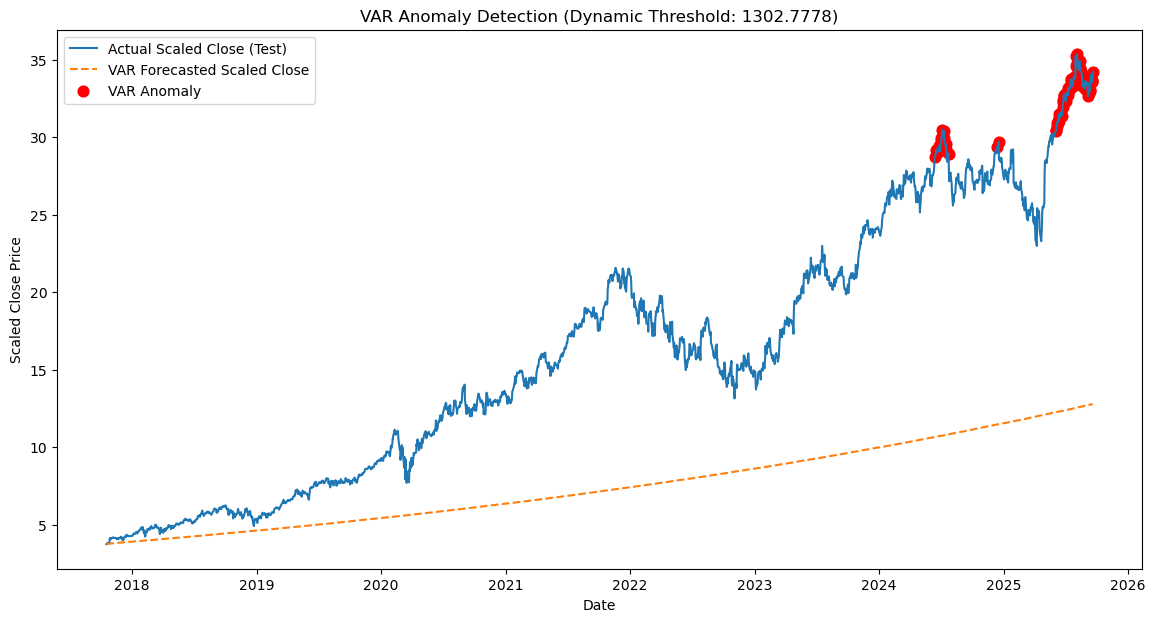

In [ ]:
var_prediction_errors = test_scaled - forecast_df
# Calculate a single anomaly score per timestep for VAR by summing squared errors across features
var_anomaly_scores = (var_prediction_errors**2).sum(axis=1)

# Define a dynamic threshold for VAR anomalies (e.g., 95th percentile)
var_threshold = np.percentile(var_anomaly_scores, 95)
var_anomalies = np.where(var_anomaly_scores > var_threshold, 1, 0)

print(f"Dynamic threshold for VAR anomaly detection (95th percentile of squared errors): {var_threshold:.4f}")
print(f"Number of VAR anomalies detected using dynamic thresholding: {np.sum(var_anomalies)}")

# Calculate RMSE and Residual Variance for VAR anomalous points
anomalous_indices_var = (var_anomalies == 1)

if np.sum(anomalous_indices_var) > 0:
    # Filter the actual and forecasted values to only include anomalous timesteps
    actual_anomalous_var = test_scaled[anomalous_indices_var].values.flatten()
    forecast_anomalous_var = forecast_df[anomalous_indices_var].values.flatten()

    # Calculate RMSE for VAR anomalous points
    rmse_var_anomalies = np.sqrt(mean_squared_error(actual_anomalous_var, forecast_anomalous_var))

    # Calculate residual errors and variance for VAR anomalous points
    residual_errors_var = actual_anomalous_var - forecast_anomalous_var
    residual_variance_var = np.var(residual_errors_var)

    print(f"RMSE for VAR anomalous points: {rmse_var_anomalies:.4f}")
    print(f"Residual Variance for VAR anomalous points: {residual_variance_var:.4f}")
else:
    print("No VAR anomalies detected to calculate RMSE and Residual Variance for.")


# Optional: Visualize VAR anomalies
plt.figure(figsize=(14, 7))
plt.plot(df.index[-len(test_scaled):], test_scaled["Close"], label="Actual Scaled Close (Test)", linewidth=1.5)
plt.plot(df.index[-len(test_scaled):], forecast_df["Close"], label="VAR Forecasted Scaled Close", linewidth=1.5, linestyle='--')
plt.scatter(test_scaled.index[anomalous_indices_var],
            test_scaled["Close"][anomalous_indices_var],
            color='red', s=60, label="VAR Anomaly")
plt.title(f"VAR Anomaly Detection (Dynamic Threshold: {var_threshold:.4f})")
plt.xlabel("Date")
plt.ylabel("Scaled Close Price")
plt.legend()
plt.show()

## LSTM MODEL

In [13]:
scaler_lstm = MinMaxScaler()
residuals_scaled = pd.DataFrame(scaler_lstm.fit_transform(residuals), columns=residuals.columns, index=residuals.index)

In [14]:
def create_sequences(X, seq_len=10):
    Xs, ys = [], []
    for i in range(len(X) - seq_len):
        Xs.append(X.iloc[i:i+seq_len].values)
        ys.append(X.iloc[i+seq_len].values)
    return np.array(Xs), np.array(ys)

In [ ]:
seq_len = 10
X, y = create_sequences(residuals_scaled, seq_len)
split = int(0.8 * len(X))
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]
print(f"LSTM data shapes: X_train={X_train.shape}, X_test={X_test.shape}")

✅ LSTM data shapes: X_train=(1585, 10, 5), X_test=(397, 10, 5)


In [16]:
lstm = Sequential([
    LSTM(64, activation='relu', input_shape=(seq_len, X_train.shape[2]), return_sequences=True),
    Dropout(0.2),
    LSTM(32, activation='relu'),
    Dense(X_train.shape[2])
])
lstm.compile(optimizer=Adam(learning_rate=0.001), loss='mse')
history = lstm.fit(X_train, y_train, epochs=30, batch_size=32, validation_split=0.1, shuffle=False, verbose=1)

c:\Users\user\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/30
45/45 ━━━━━━━━━━━━━━━━━━━━ 76s 92ms/step - loss: 0.0124 - val_loss: 0.0133
Epoch 2/30
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - loss: 0.0103 - val_loss: 0.0076
Epoch 3/30
45/45 ━━━━━━━━━━━━━━━━━━━━ 2s 33ms/step - loss: 0.0069 - val_loss: 0.0058
Epoch 4/30
45/45 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step - loss: 0.0049 - val_loss: 0.0027
Epoch 5/30
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - loss: 0.0036 - val_loss: 0.0029
Epoch 6/30
45/45 ━━━━━━━━━━━━━━━━━━━━ 3s 31ms/step - loss: 0.0035 - val_loss: 0.0044
Epoch 7/30
45/45 ━━━━━━━━━━━━━━━━━━━━ 2s 35ms/step - loss: 0.0036 - val_loss: 0.0018
Epoch 8/30
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - loss: 0.0036 - val_loss: 0.0027
Epoch 9/30
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - loss: 0.0031 - val_loss: 0.0029
Epoch 10/30
45/45 ━━━━━━━━━━━━━━━━━━━━ 2s 41ms/step - loss: 0.0026 - val_loss: 0.0022
Epoch 11/30
45/45 ━━━━━━━━━━━━━━━━━━━━ 3s 37ms/step - loss: 0.0029 - val_loss: 0.0019
Epoch 12/30
45/45 ━━━━━━━━━━━━━━━━━━━━ 3s 33ms/step - loss: 0.

In [17]:
y_pred = lstm.predict(X_test)
mse = np.mean(np.power(y_test - y_pred, 2), axis=1)

13/13 ━━━━━━━━━━━━━━━━━━━━ 3s 154ms/step


## ISOLATION FOREST

In [18]:
iso = IsolationForest(contamination=0.05, random_state=42)
labels = iso.fit_predict(mse.reshape(-1, 1))
anomalies = np.where(labels == -1, 1, 0)

In [19]:
res_index = residuals_scaled.iloc[-len(mse):].index
results = pd.DataFrame({
    "Reconstruction_Error": mse,
    "Anomaly": anomalies
}, index=res_index)

## VAR + LSTM + ISOLATION FOREST 


✅ Hybrid VAR + LSTM RMSE: 0.0593


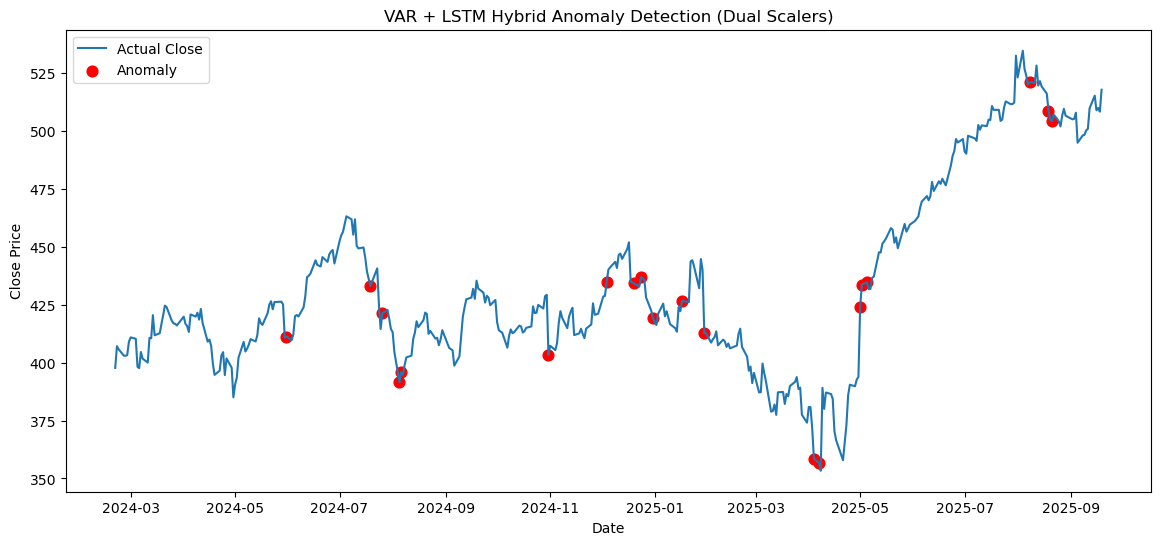

In [ ]:
rmse = np.sqrt(mean_squared_error(y_test.flatten(), y_pred.flatten()))
print(f"\nHybrid VAR + LSTM RMSE: {rmse:.4f}")

plt.figure(figsize=(14,6))
plt.plot(df.index[-len(results):], df["Close"].iloc[-len(results):], label="Actual Close", linewidth=1.5)
plt.scatter(results.index[results["Anomaly"] == 1],
            df["Close"].iloc[-len(results):][results["Anomaly"] == 1],
            color='red', s=60, label="Anomaly")
plt.title("VAR + LSTM Hybrid Anomaly Detection (Dual Scalers)")
plt.xlabel("Date")
plt.ylabel("Close Price")
plt.legend()
plt.show()

In [ ]:
# Filter the original dataframe to show the anomalous data points
anomalous_data = df.loc[results[results['Anomaly'] == 1].index]

print("\n Anomalous Data Points:")
display(anomalous_data)


✅ Anomalous Data Points:


,Close,High,Low,Open,Volume
Date,,,,,
2024-05-31,411.295288,412.900319,400.773394,412.900319,47995300
2024-07-19,433.072266,437.065068,428.009483,429.099328,20940400
2024-07-26,421.341614,424.957922,413.415513,414.336945,23583800
2024-08-05,391.499878,397.335485,382.018272,385.575136,40709200
2024-08-06,395.918671,401.922720,394.818939,396.305083,24946500
2024-10-31,403.322052,413.058949,403.272406,412.264893,53971000
2024-12-04,435.029572,437.267276,430.265740,430.663548,26009400
2024-12-20,434.214050,441.315015,426.287604,430.743102,64263700
2024-12-24,436.929108,437.197652,431.817213,432.274691,7164500


In [22]:
from sklearn.metrics import mean_squared_error

# Collect results
comparison = {
    "VAR+LSTM": {"errors": mse, "anomalies": results["Anomaly"]},

}

records = []
for name, data in comparison.items():
    rmse = np.sqrt(np.mean(np.square(data["errors"])))
    var = np.var(data["errors"])
    count = np.sum(data["anomalies"] == 1)
    records.append({
        "Model": name,
        "Anomalies Detected": count,
        "RMSE": rmse,
        "Residual Variance": var
    })

df_compare = pd.DataFrame(records)
print(df_compare)

      Model  Anomalies Detected      RMSE  Residual Variance
0  VAR+LSTM                  20  0.004524           0.000008


### VAR + LSTM + ISOLATION FOREST USING STATIC THRESHHOLDING

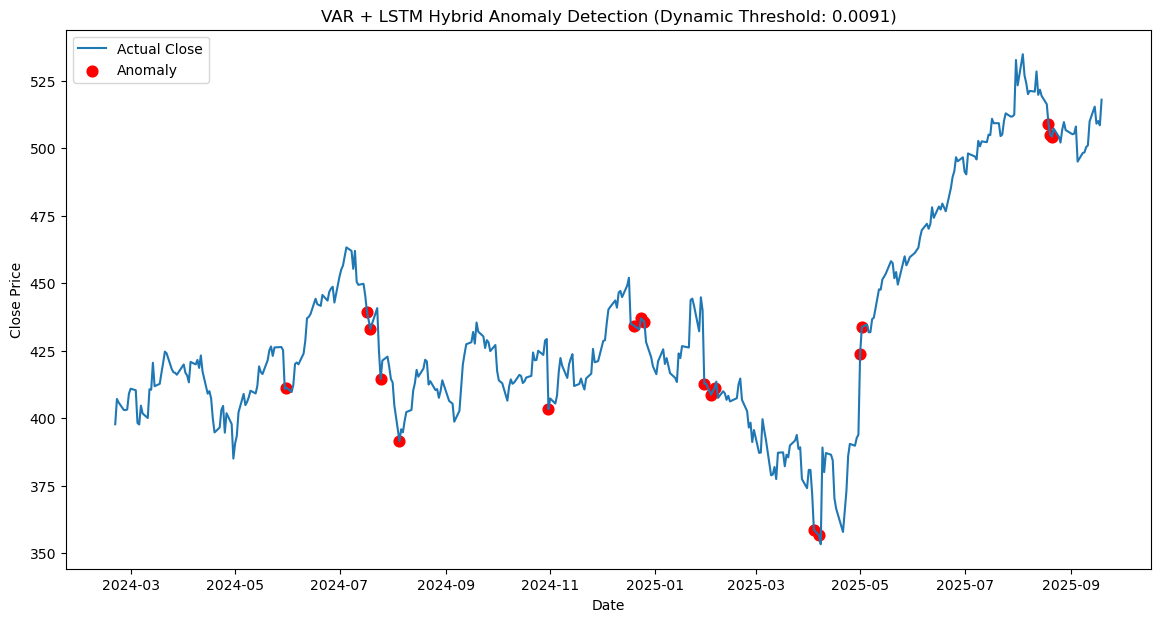

✅ Dynamic threshold for anomaly detection (95th percentile of MSE): 0.0091
✅ Number of anomalies detected using dynamic thresholding: 20
✅ RMSE for anomalous points: 0.1073
✅ Residual Variance for anomalous points: 0.0086


In [ ]:
threshold = np.percentile(mse, 95)
anomalies = np.where(mse > threshold, 1, 0)

results['Anomaly'] = anomalies

# Visualize anomalies with thresholding
plt.figure(figsize=(14, 7))
plt.plot(df.index[-len(results):], df["Close"].iloc[-len(results):], label="Actual Close", linewidth=1.5)
plt.scatter(results.index[results["Anomaly"] == 1],
            df["Close"].iloc[-len(results):][results["Anomaly"] == 1],
            color='red', s=60, label="Anomaly")
plt.title(f"VAR + LSTM Hybrid Anomaly Detection (Dynamic Threshold: {threshold:.4f})")
plt.xlabel("Date")
plt.ylabel("Close Price")
plt.legend()
plt.show()

# Corrected RMSE calculation for anomalous points
anomalous_indices = (anomalies == 1)
rmse_anomalies = np.sqrt(mean_squared_error(y_test[anomalous_indices].flatten(), y_pred[anomalous_indices].flatten()))

# Calculate residual variance for anomalous points
residual_errors_anomalies = (y_test[anomalous_indices] - y_pred[anomalous_indices]).flatten()
residual_variance_anomalies = np.var(residual_errors_anomalies)

print(f" Dynamic threshold for anomaly detection (95th percentile of MSE): {threshold:.4f}")
print(f" Number of anomalies detected using dynamic thresholding: {np.sum(anomalies)}")
print(f" RMSE for anomalous points: {rmse_anomalies:.4f}")
print(f" Residual Variance for anomalous points: {residual_variance_anomalies:.4f}")

Using dynamic thresholding yielded more stable results compared to when using static thresholding 

Compared to the Statistical model, the hybrid showed better performance even though it detected less, this assumes errors made by the statistcal model were corrected by the hybrid model 

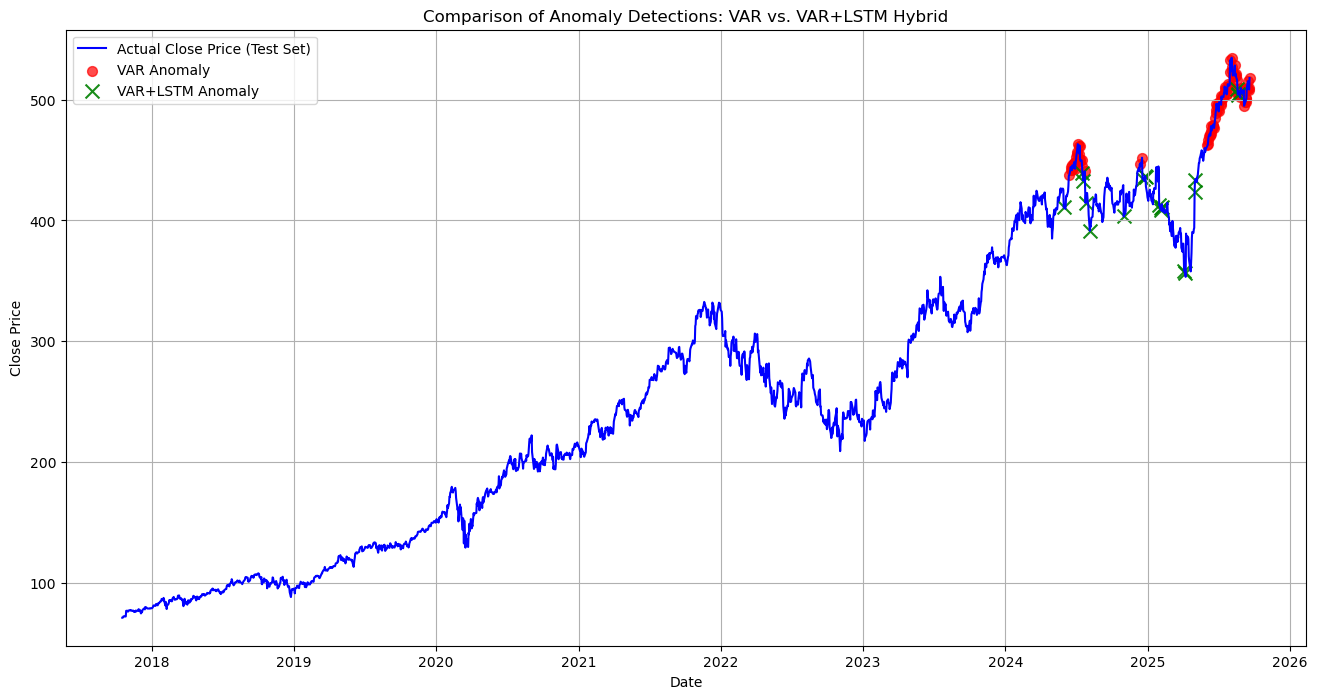


✅ Comparison graph generated showing anomalies from both models.


In [ ]:
import matplotlib.pyplot as plt

# Create a DataFrame for VAR anomalies to align with test_df index
var_anomalies_df = pd.DataFrame({
    "Anomaly": var_anomalies
}, index=test_scaled.index)

plt.figure(figsize=(16, 8))
plt.plot(test_df.index, test_df["Close"], label="Actual Close Price (Test Set)", color='blue', linewidth=1.5)

# Plot VAR anomalies
var_anomalous_dates = var_anomalies_df[var_anomalies_df["Anomaly"] == 1].index
plt.scatter(var_anomalous_dates,
            test_df.loc[var_anomalous_dates, "Close"],
            color='red', marker='o', s=50, label="VAR Anomaly", alpha=0.7)

# Plot VAR+LSTM anomalies
lstm_anomalous_dates = results[results["Anomaly"] == 1].index
plt.scatter(lstm_anomalous_dates,
            test_df.loc[lstm_anomalous_dates, "Close"],
            color='green', marker='x', s=100, label="VAR+LSTM Anomaly", alpha=0.9)

plt.title("Comparison of Anomaly Detections: VAR vs. VAR+LSTM Hybrid")
plt.xlabel("Date")
plt.ylabel("Close Price")
plt.legend()
plt.grid(True)
plt.show()

print("\n Comparison graph generated showing anomalies from both models.")

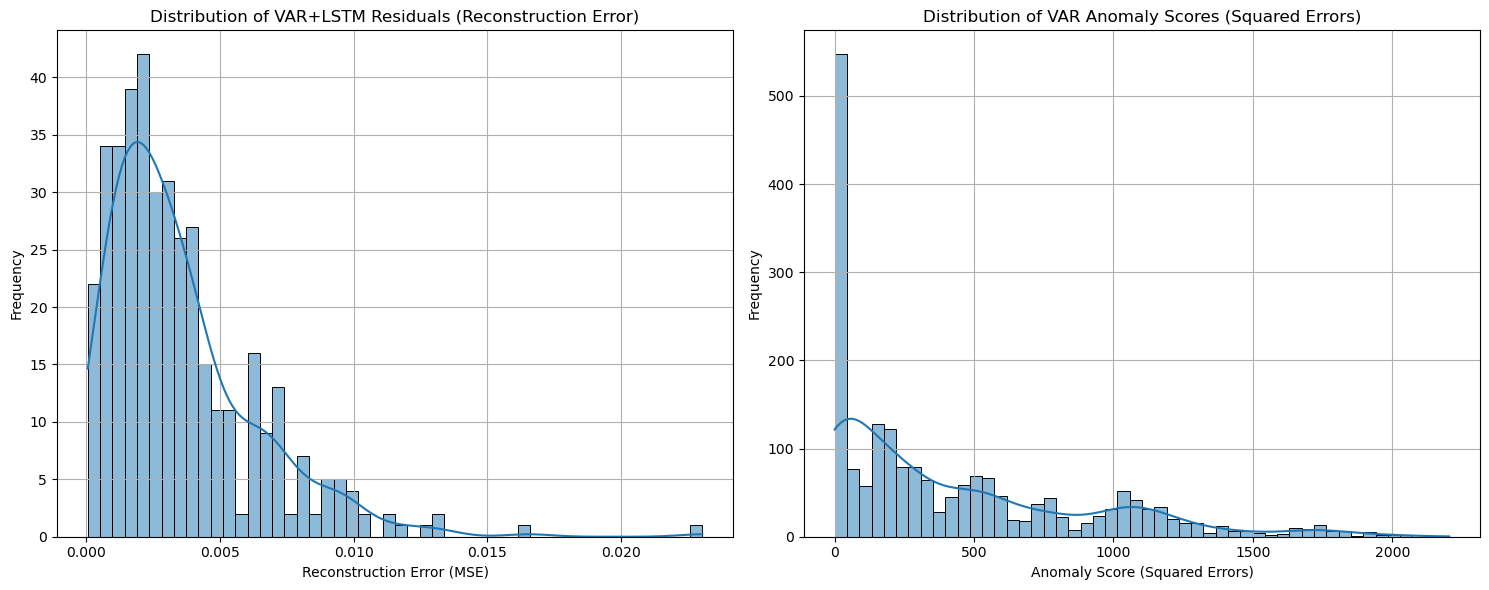

✅ Comparison of residual distribution plots generated.


In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 6))

plt.subplot(1, 2, 1)
sns.histplot(mse, bins=50, kde=True)
plt.title('Distribution of VAR+LSTM Residuals (Reconstruction Error)')
plt.xlabel('Reconstruction Error (MSE)')
plt.ylabel('Frequency')
plt.grid(True)

plt.subplot(1, 2, 2)
sns.histplot(var_anomaly_scores, bins=50, kde=True)
plt.title('Distribution of VAR Anomaly Scores (Squared Errors)')
plt.xlabel('Anomaly Score (Squared Errors)')
plt.ylabel('Frequency')
plt.grid(True)

plt.tight_layout()
plt.show()

print(" Comparison of residual distribution plots generated.")

#### SAVING MODELS

models are ready to used for integration

In [ ]:
import joblib

joblib.dump(var_fit, 'var_model.pkl')

# Save the scaler_var object
joblib.dump(scaler_var, 'var_scaler.pkl')

# Save the lstm model with a .keras extension
lstm.save('./lstm_model.keras')

# Save the scaler_lstm object
joblib.dump(scaler_lstm, 'lstm_scaler.pkl')

# Save the IsolationForest model
joblib.dump(iso, 'isolation_forest_model.pkl')


['isolation_forest_model.pkl']